In [ ]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import json
import statistics
import numpy as np


def std_bar(mean, std):
    tmp_mean = np.array(mean)
    tmp_std = np.array(std)
    
    return tmp_mean - tmp_std, tmp_mean + tmp_std


def plot_res(tmp_path, tmp_path2, tmp_path_unpruned, model_name, datasets, fa_approach, threshold=0.1):

    
    d_names = {
    "rte":"RTE",
    "arc_challenge":"ARC Challenge",
    "openbookqa":"OpenBookQA",
    "boolq":"BoolQ",
    "arc_easy":"ARC Easy"
    }


    num = 16

    colors = {"s":"#fc5e03", "c":"#030ffc"}
    for dataset in datasets:
        
        if tmp_path_unpruned is not None:
            acc = 0

            c_unpruned = 0
            
            for i in range(3):
                
                out_file = open(tmp_path_unpruned+model_name+"_"+fa_approach+"_res_3d_"+str(i)+".json", "r")
                out = json.load(out_file)
                out_file.close()
                
                c_unpruned += out[dataset]["comp"]
                
            out_file = open(tmp_path_unpruned+model_name+".json", "r")
            out = json.load(out_file)
            out_file.close()
            
            acc = out["results"][dataset]["acc,none"]

            c_unpruned/=3
            
        
            

        comp = []
        std_comp = []
        
        accs = []

        for i in range(num):
            tmp_comp = []
            tmp_accs = []
            
            
            for j in range(3):
                
                out_file = open(tmp_path+model_name+"_"+str(i)+"_"+fa_approach+"_res_3d_"+str(j)+".json", "r")
                out = json.load(out_file)
                out_file.close()
                

                tmp_comp.append(out[dataset]["comp"])
                
                
                
            out_file = open(tmp_path2+model_name+"_"+str(i)+".json", "r")
            out = json.load(out_file)
            out_file.close()
            
            tmp_accs = np.array(out["results"][dataset]["acc,none"])    


            comp.append(statistics.mean(tmp_comp))
            accs.append(tmp_accs)
        
            std_comp.append(statistics.stdev(tmp_comp))
        
        # Comprehensiveness

        fig, ax1 = plt.subplots()
        x_values = list(range(1, len(comp) + 1))
        l = len(x_values)
        
        
        p1 = -(np.array(c_unpruned)-np.array(comp))/np.array(c_unpruned)
        p2 = -(np.array(acc) - np.array(accs))/np.array(acc)

        ma = max(max(abs(p2)),max(abs(p1)))   
        mi = - ma
        
        
        lns4 = ax1.plot(x_values, p1, label='comprehensiveness delta', color=colors["c"])
        lns6 = ax1.plot(x_values, p2, label='accuracy', color="black")
        
        
        ax1.set_ylim([mi, ma])
        ax1.set_xlim(x_values[0],x_values[-1])
        
        lns5 = ax1.plot(x_values, [0]*l, label='', color="black", linestyle='--')
        
        ax1.set_xlabel('# removed attention layers', fontsize=18)
        ax1.set_ylabel('Delta\nunpruned is better | pruned is better   ', fontsize=16)
        plt.tick_params(axis='both', which='major', labelsize=14)
        
        plt.title(d_names[dataset], fontsize=20)
        
        h_comp = mpatches.Patch(color="#030ffc")
        h_acc = mpatches.Patch(color="black")

        fig.tight_layout()
        plt.savefig("results/plots/deltas/comp/"+dataset+"_"+model_name+"_"+fa_approach+"_delta.pdf", dpi=600)
        plt.show()
        

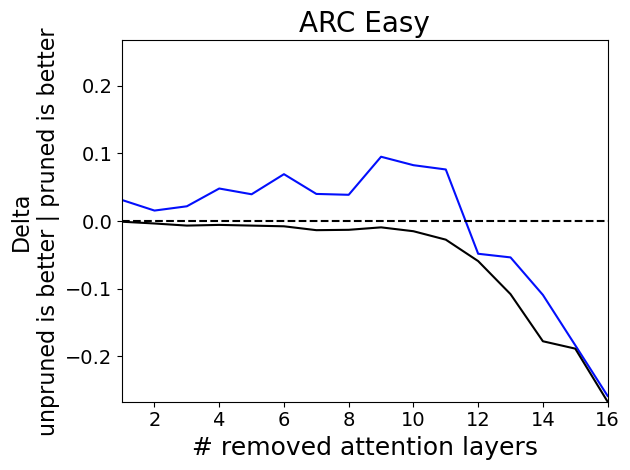

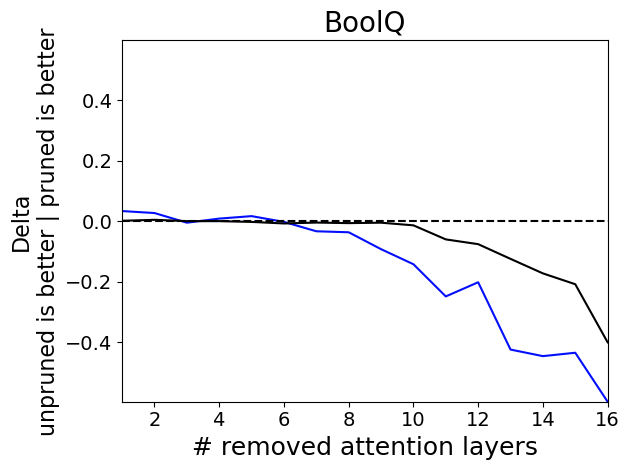

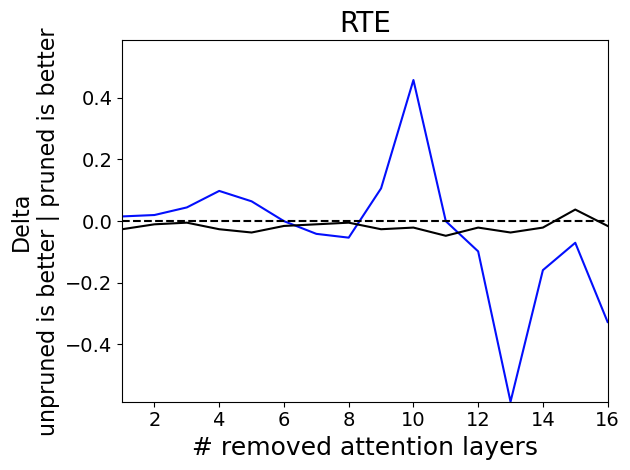

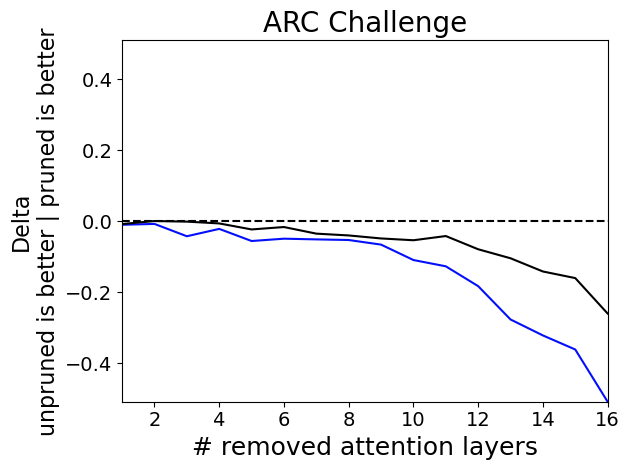

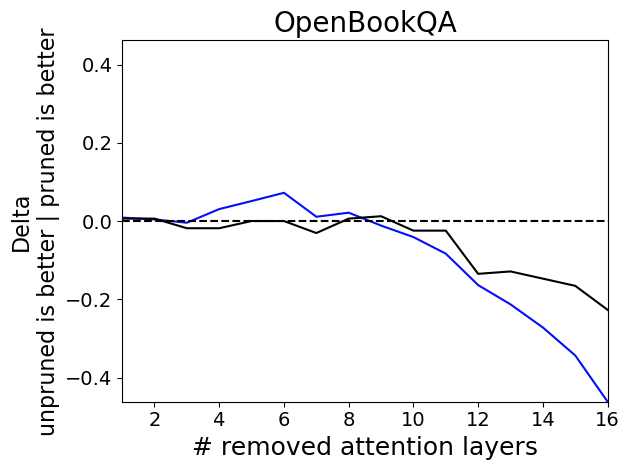

In [45]:
datasets = ["arc_easy","boolq","rte","arc_challenge","openbookqa"]
model_name = "Mistral-7B-v0.1"
tmp_path = "./results/pruned/seeds/mistralai/"
tmp_path2 = "./results/pruned/mistralai/"
tmp_path_unpruned = "./results/unpruned/seeds/mistralai/"
fa_approach = "ks"

plot_res(tmp_path, tmp_path2, tmp_path_unpruned, model_name, datasets, fa_approach)

In [ ]:
datasets = ["arc_easy","boolq","rte","arc_challenge","openbookqa"]
model_name = "Mistral-7B-v0.1"
tmp_path = "./results/pruned/seeds/mistralai/"
tmp_path2 = "./results/pruned/mistralai/"
tmp_path_unpruned = "./results/unpruned/seeds/mistralai/"
fa_approach = "lime"

plot_res(tmp_path, tmp_path2, tmp_path_unpruned, model_name, datasets, fa_approach)

In [ ]:
datasets = ["arc_easy","boolq","rte","arc_challenge","openbookqa"]
model_name = "Llama-2-7b-hf"
tmp_path = "./results/pruned/seeds/meta-llama/"
tmp_path2 = "./results/pruned/meta-llama/"
tmp_path_unpruned =  "./results/unpruned/seeds/meta-llama/"
fa_approach = "lime"

plot_res(tmp_path, tmp_path2, tmp_path_unpruned, model_name, datasets, fa_approach)

In [ ]:
datasets = ["arc_easy","boolq","rte","arc_challenge","openbookqa"]
model_name = "Llama-2-7b-hf"
tmp_path = "./results/pruned/seeds/meta-llama/"
tmp_path2 = "./results/pruned/meta-llama/"
tmp_path_unpruned =  "./results/unpruned/seeds/meta-llama/"
fa_approach = "ks"

plot_res(tmp_path, tmp_path2, tmp_path_unpruned, model_name, datasets, fa_approach)

In [ ]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import json
import statistics
import numpy as np


def std_bar(mean, std):
    tmp_mean = np.array(mean)
    tmp_std = np.array(std)
    
    return tmp_mean - tmp_std, tmp_mean + tmp_std


def plot_res(tmp_path, tmp_path2, tmp_path_unpruned, model_name, datasets, fa_approach, threshold=0.1):


    d_names = {
    "rte":"RTE",
    "arc_challenge":"ARC Challenge",
    "openbookqa":"OpenBookQA",
    "boolq":"BoolQ",
    "arc_easy":"ARC Easy"
    }
        
    num = 16
    if "gemma" in model_name:
        num = 9
        
    colors = {"s":"#fc5e03", "c":"#030ffc"}
    for dataset in datasets:
        
        if tmp_path_unpruned is not None:
            acc = 0
            s_unpruned = 0

            
            for i in range(3):
                
                out_file = open(tmp_path_unpruned+model_name+"_"+fa_approach+"_res_3d_"+str(i)+".json", "r")
                out = json.load(out_file)
                out_file.close()
                
                s_unpruned += out[dataset]["suff"]

            out_file = open(tmp_path_unpruned+model_name+".json", "r")
            out = json.load(out_file)
            out_file.close()
            
            acc = out["results"][dataset]["acc,none"]
            
            s_unpruned/=3
            
        suff = []   
        std_suff = []
        accs = []

        for i in range(num):
            
            tmp_suff =[]
            tmp_accs = []
            
            
            for j in range(3):
                
                out_file = open(tmp_path+model_name+"_"+str(i)+"_"+fa_approach+"_res_3d_"+str(j)+".json", "r")
                out = json.load(out_file)
                out_file.close()
                
                tmp_suff.append(out[dataset]["suff"])
                
                
                
            out_file = open(tmp_path2+model_name+"_"+str(i)+".json", "r")
            out = json.load(out_file)
            out_file.close()
            
            tmp_accs = np.array(out["results"][dataset]["acc,none"])    
        

            
            suff.append(statistics.mean(tmp_suff))
            accs.append(tmp_accs)
            std_suff.append(statistics.stdev(tmp_suff))

        
        # Comprehensiveness

        fig, ax1 = plt.subplots()
        x_values = list(range(1, len(suff) + 1))
        l = len(x_values)
        

        p = (np.array(s_unpruned) - np.array(suff))/np.array(s_unpruned) 
        p2 = -(np.array(acc) - np.array(accs))/np.array(acc)
        
        ma = max(max(abs(p2)),max(abs(p)))   
        mi = - ma
        
        
        lns4 = ax1.plot(x_values, p, label='sufficiency delta', color=colors["s"])
        lns6 = ax1.plot(x_values, p2, label='accuracy', color="black")
        
        
        ax1.set_ylim([mi, ma])
        ax1.set_xlim(x_values[0],x_values[-1])
        
        lns5 = ax1.plot(x_values, [0]*l, label='', color="black", linestyle='--')
        

        ax1.set_xlabel('# removed attention layers', fontsize=18)
        ax1.set_ylabel('Delta\nunpruned is better | pruned is better   ', fontsize=16)
        plt.tick_params(axis='both', which='major', labelsize=14)
        
        plt.title(d_names[dataset], fontsize=20)
         
        fig.tight_layout()
        plt.savefig("results/plots/deltas/suff/"+dataset+"_"+model_name+"_"+fa_approach+"_delta.pdf", dpi=600)
        plt.show()


In [ ]:
datasets = ["arc_easy","boolq","rte","arc_challenge","openbookqa"]
model_name = "Mistral-7B-v0.1"
tmp_path = "./results/pruned/seeds/mistralai/"
tmp_path2 = "./results/pruned/mistralai/"
tmp_path_unpruned = "./results/unpruned/seeds/mistralai/"
fa_approach = "ks"

plot_res(tmp_path, tmp_path2, tmp_path_unpruned, model_name, datasets, fa_approach)

In [ ]:
datasets = ["arc_easy","boolq","rte","arc_challenge","openbookqa"]
model_name = "Mistral-7B-v0.1"
tmp_path = "./results/pruned/seeds/mistralai/"
tmp_path2 = "./results/pruned/mistralai/"
tmp_path_unpruned = "./results/unpruned/seeds/mistralai/"
fa_approach = "lime"

plot_res(tmp_path, tmp_path2, tmp_path_unpruned, model_name, datasets, fa_approach)

In [ ]:
datasets = ["arc_easy","boolq","rte","arc_challenge","openbookqa"]
model_name = "Llama-2-7b-hf"
tmp_path = "./results/pruned/seeds/meta-llama/"
tmp_path2 = "./results/pruned/meta-llama/"
tmp_path_unpruned =  "./results/unpruned/seeds/meta-llama/"
fa_approach = "lime"

plot_res(tmp_path, tmp_path2, tmp_path_unpruned, model_name, datasets, fa_approach)

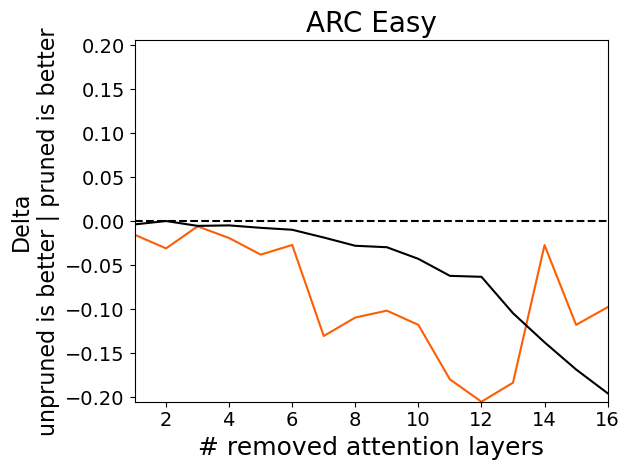

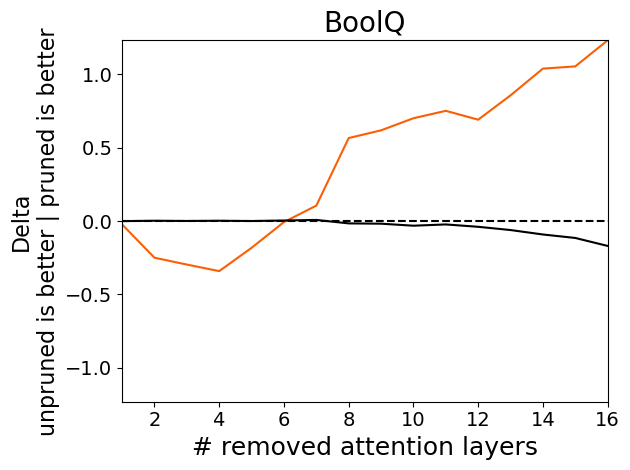

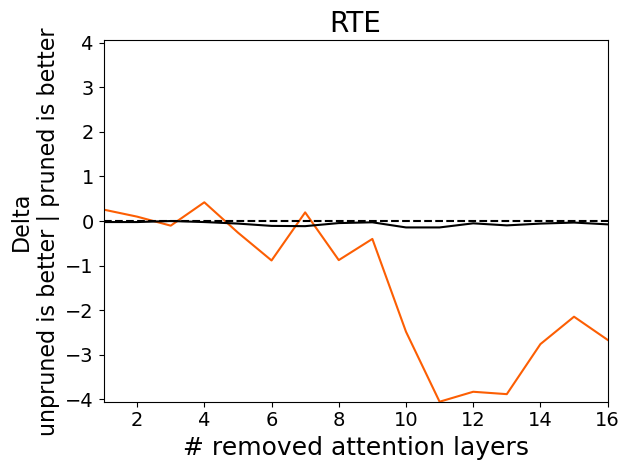

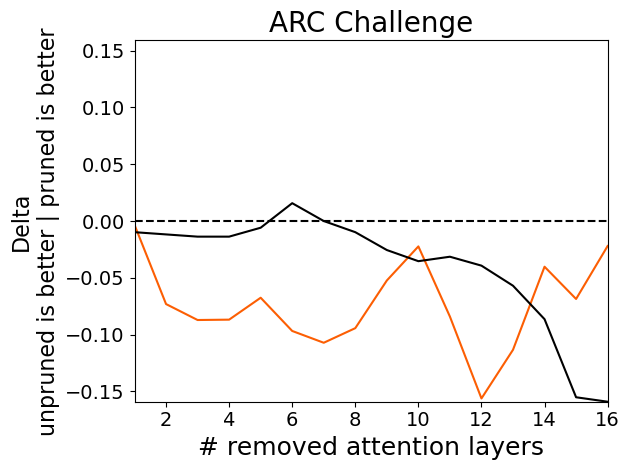

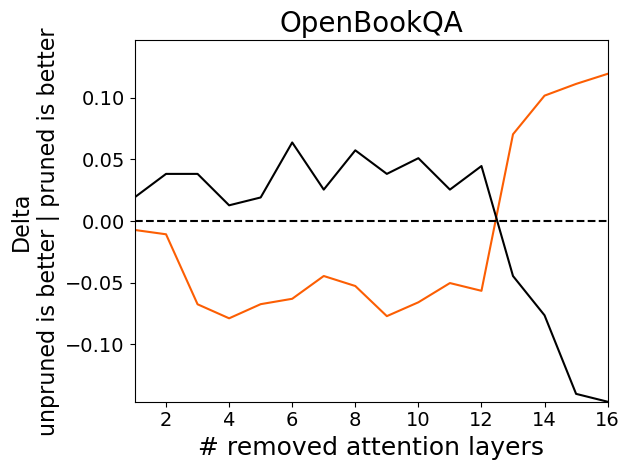

In [55]:
datasets = ["arc_easy","boolq","rte","arc_challenge","openbookqa"]
model_name = "Llama-2-7b-hf"
tmp_path = "./results/pruned/seeds/meta-llama/"
tmp_path2 = "./results/pruned/meta-llama/"
tmp_path_unpruned =  "./results/unpruned/seeds/meta-llama/"
fa_approach = "ks"

plot_res(tmp_path, tmp_path2, tmp_path_unpruned, model_name, datasets, fa_approach)

In [ ]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import json
import statistics
import numpy as np


def plot_avg_res(tmp_paths, tmp_paths2, tmp_paths_unpruned, model_names, datasets, fa_approach, threshold=0.1):
    num = 16
    colors = {"s": "#fc5e03", "c": "#030ffc"}
    
    avg_comp = []
    avg_suff = []
    avg_acc = []
    
    for dataset in datasets:
        dataset_comp = []
        dataset_suff = []
        dataset_acc = []
        

        for model_name in model_names:
            
            tmp_path = tmp_paths[model_name]
            tmp_path2 = tmp_paths2[model_name]
            tmp_path_unpruned = tmp_paths_unpruned[model_name]
            
            if tmp_path_unpruned is not None:
                acc = 0
                c_unpruned = 0
                s_unpruned = 0
                
                for i in range(3):
                    out_file = open(tmp_path_unpruned + model_name + "_" + fa_approach + "_res_3d_" + str(i) + ".json", "r")
                    out = json.load(out_file)
                    out_file.close()
                    
                    c_unpruned += out[dataset]["comp"]
                    s_unpruned += out[dataset]["suff"]
                
                out_file = open(tmp_path_unpruned + model_name + ".json", "r")
                out = json.load(out_file)
                out_file.close()
                
                acc = out["results"][dataset]["acc,none"]
                c_unpruned /= 3
                s_unpruned /= 3
            
            comp = []
            suff = []
            accs = []
            
            for i in range(num):
                tmp_comp = []
                tmp_suff = []
                tmp_accs = []
                
                for j in range(3):
                    out_file = open(tmp_path + model_name + "_" + str(i) + "_" + fa_approach + "_res_3d_" + str(j) + ".json", "r")
                    out = json.load(out_file)
                    out_file.close()
                    
                    tmp_comp.append(out[dataset]["comp"])
                    tmp_suff.append(out[dataset]["suff"])
                
                out_file = open(tmp_path2 + model_name + "_" + str(i) + ".json", "r")
                out = json.load(out_file)
                out_file.close()
                
                tmp_accs = np.array(out["results"][dataset]["acc,none"])

                a = statistics.mean(tmp_comp)
                b = statistics.mean(tmp_suff)  
                comp.append(-(np.array(c_unpruned)-np.array(a))/np.array(c_unpruned))
                suff.append((np.array(s_unpruned) - np.array(b))/np.array(s_unpruned))
                accs.append(-(np.array(acc) - np.array(tmp_accs))/np.array(acc))
            
            dataset_comp.append(comp)
            dataset_suff.append(suff)
            dataset_acc.append(accs)
        
        
        avg_comp.append(np.mean(dataset_comp, axis=0))
        avg_suff.append(np.mean(dataset_suff, axis=0))
        avg_acc.append(np.mean(dataset_acc, axis=0))
        
    
    # Plot averaged comprehensiveness
    fig, ax1 = plt.subplots()
    x_values = list(range(1, num + 1))
    
    avg_comp_delta = np.mean(avg_comp, axis=0)
    avg_acc_delta = np.mean(avg_acc, axis=0)
    avg_suff_delta = np.mean(avg_suff, axis=0)
    
    ma = max(max(abs(avg_comp_delta)), max(abs(avg_suff_delta)), max(abs(avg_acc_delta)))
    mi = -ma
    
    ax1.plot(x_values, avg_comp_delta, label='Avg Comprehensiveness Delta', color=colors["c"])
    ax1.plot(x_values, avg_acc_delta, label='Avg Accuracy Delta', color="black")
    ax1.plot(x_values, [0] * num, label='', color="black", linestyle='--')
    ax1.plot(x_values, avg_suff_delta, label='Avg Sufficiency Delta', color=colors["s"])
    
    ax1.set_ylim([mi, ma])
    ax1.set_xlim(x_values[0], x_values[-1])
    ax1.set_xlabel('# removed attention layers', fontsize=18)
    ax1.set_ylabel('Delta\nunpruned is better | pruned is better   ', fontsize=16)
    plt.tick_params(axis='both', which='major', labelsize=14)
    plt.xlim(1,16)

    
    m_n = "Mistral"
    if "ama" in model_names[0]:
        m_n = "Llama-2"
        
    if fa_approach == "lime":
        plt.title("LIME, "+m_n, fontsize=20)
    else:
        tmp_fa_approach = "fa_kernel_shap"
        plt.title("Kernel SHAP, "+m_n, fontsize=20)
        
    
    fig.tight_layout()
    plt.savefig("results/plots/deltas/averaged_comp_suff_"+fa_approach+"_"+model_names[0]+".pdf", dpi=600)
    plt.show()

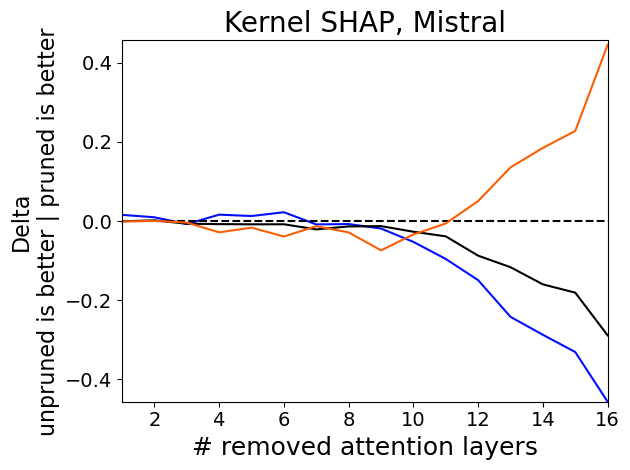

In [ ]:
tmp_paths = {
    "Mistral-7B-v0.1": "./results/pruned/seeds/mistralai/",
    "Llama-2-7b-hf": "./results/pruned/seeds/meta-llama/"
}

tmp_paths2 = {
    "Mistral-7B-v0.1": "./results/pruned/mistralai/",
    "Llama-2-7b-hf": "./results/pruned/meta-llama/"
}

tmp_paths_unpruned = {
    "Mistral-7B-v0.1": "./results/unpruned/seeds/mistralai/",
    "Llama-2-7b-hf": "./results/unpruned/seeds/meta-llama/"
}

model_names = ["Mistral-7B-v0.1"]
datasets = ["arc_easy", "boolq", "arc_challenge", "openbookqa"] # "rte"
fa_approach = "ks"

plot_avg_res(tmp_paths, tmp_paths2, tmp_paths_unpruned, model_names, datasets, fa_approach)

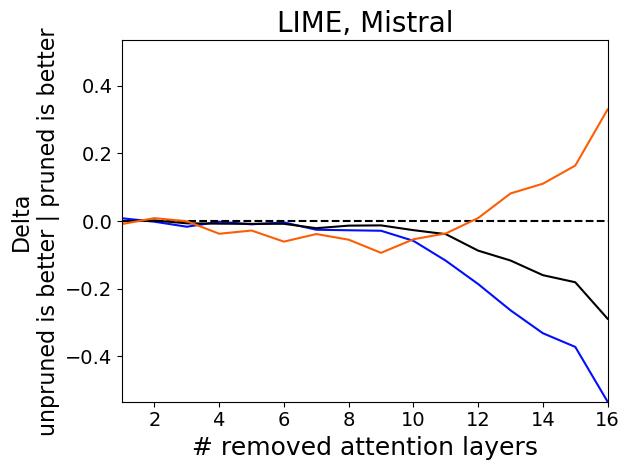

In [ ]:
model_names = ["Mistral-7B-v0.1"]
fa_approach = "lime"

plot_avg_res(tmp_paths, tmp_paths2, tmp_paths_unpruned, model_names, datasets, fa_approach)

In [ ]:
model_names = ["Llama-2-7b-hf"]
fa_approach = "ks"

plot_avg_res(tmp_paths, tmp_paths2, tmp_paths_unpruned, model_names, datasets, fa_approach)

In [ ]:
model_names = ["Llama-2-7b-hf"]
fa_approach = "lime"

plot_avg_res(tmp_paths, tmp_paths2, tmp_paths_unpruned, model_names, datasets, fa_approach)